# Ch 15 — 보스턴 집값 예측 (회귀)

원본: `13_Boston.py`

다루는 내용:
1. 공백 구분 CSV 로드
2. 13개 입력 → 1개 실수 출력
3. MSE 손실 + MAE 지표
4. 예측값 vs 실제값 비교

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

from sklearn.model_selection import train_test_split

2026-05-12 17:33:26.399178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778574806.419122 1731775 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778574806.424917 1731775 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 로드

> ⚠ 보스턴 집값 데이터는 컬럼 `B` (인종 관련) 때문에 sklearn 1.2부터 제거됨.
> 본 노트북은 *학습 목적의 토이 예제*로만 사용.

In [2]:
DATA = "../../data/housing.csv"
df = pd.read_csv(DATA, sep=r"\s+", header=None)  # ← delim_whitespace 대체
print("shape:", df.shape)
df.head()

shape: (506, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


컬럼 의미 (참고):

| # | 이름 | 의미 |
| - | - | - |
| 0 | CRIM | 인당 범죄율 |
| 1 | ZN | 25000 sq.ft 이상 거주지역 비율 |
| 2 | INDUS | 비소매업 면적 비율 |
| 3 | CHAS | 찰스강 인접 (0/1) |
| 4 | NOX | 일산화질소 농도 |
| 5 | RM | 주택당 평균 방 수 |
| 6 | AGE | 1940년 이전 건축 비율 |
| 7 | DIS | 5개 직업센터까지의 가중거리 |
| 8 | RAD | 고속도로 접근성 지수 |
| 9 | TAX | 재산세율 |
| 10 | PTRATIO | 학생/교사 비율 |
| 11 | B | (인종 관련 — 윤리적 이유로 비권장) |
| 12 | LSTAT | 저소득층 비율 |
| 13 | MEDV | **집값 중간값 (천 달러)** ← 라벨 |

## 2. 입력/라벨 분리 + train/test

In [3]:
X = df.iloc[:, 0:13].to_numpy(dtype="float32")
y = df.iloc[:, 13].to_numpy(dtype="float32")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
print("train:", X_tr.shape, "test:", X_te.shape)
print(f"y 범위: {y.min():.1f} ~ {y.max():.1f}  (단위: 천 달러)")

train: (354, 13) test: (152, 13)
y 범위: 5.0 ~ 50.0  (단위: 천 달러)


## 3. 모델 — 출력층은 활성화 없음

회귀에서 출력층에 sigmoid/softmax를 쓰면 출력 범위가 제한되어 안 됨. 그냥 선형(`Dense(1)`).

In [4]:
keras.utils.set_random_seed(0)
model = Sequential([
    Input(shape=(13,)),
    Dense(30, activation="relu"),
    Dense(6,  activation="relu"),
    Dense(1),  # ← 활성화 없음
])
model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
model.summary()

2026-05-12 17:33:28.748352: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           186 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613 (2.39 KB)

 Trainable params: 613 (2.39 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 학습

In [5]:
hist = model.fit(X_tr, y_tr, epochs=200, batch_size=10,
                 validation_data=(X_te, y_te), verbose=0)

mse = hist.history["loss"][-1]
val_mse = hist.history["val_loss"][-1]
mae = hist.history["mae"][-1]
val_mae = hist.history["val_mae"][-1]
print(f"train  MSE = {mse:.2f}  MAE = {mae:.2f}")
print(f"val    MSE = {val_mse:.2f}  MAE = {val_mae:.2f}")
print(f"\n평균적으로 약 {val_mae:.1f} (천 달러) 정도 빗나감")

train  MSE = 14.48  MAE = 2.78
val    MSE = 24.47  MAE = 3.55

평균적으로 약 3.6 (천 달러) 정도 빗나감


## 5. 학습 곡선

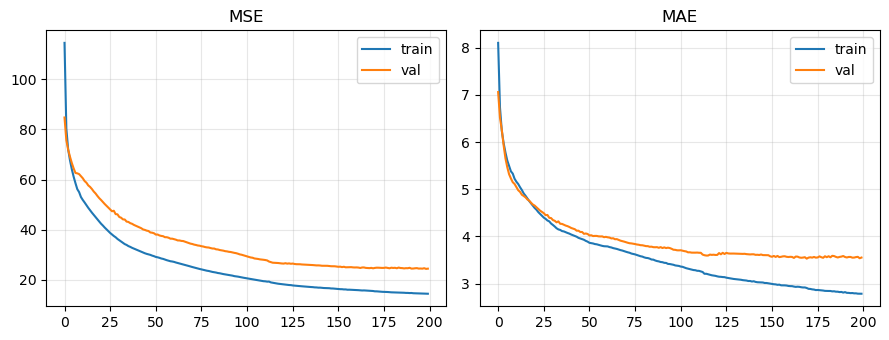

In [6]:
plt.figure(figsize=(9, 3.5))
plt.subplot(1, 2, 1)
plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="val")
plt.title("MSE"); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(hist.history["mae"], label="train"); plt.plot(hist.history["val_mae"], label="val")
plt.title("MAE"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 예측값 vs 실제값

/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

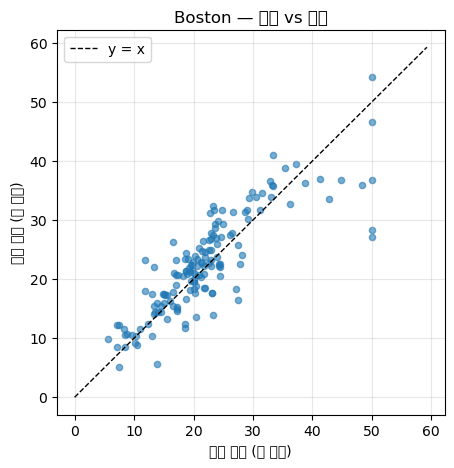

In [7]:
y_pred = model.predict(X_te, verbose=0).flatten()

plt.figure(figsize=(5, 5))
plt.scatter(y_te, y_pred, s=20, alpha=0.6)
m = max(y.max(), y_pred.max()) + 5
plt.plot([0, m], [0, m], "k--", lw=1, label="y = x")
plt.xlabel("실제 가격 (천 달러)"); plt.ylabel("예측 가격 (천 달러)")
plt.title("Boston — 예측 vs 실제"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [8]:
print(f"{'실제':>8}  {'예측':>8}  {'오차':>8}")
for actual, pred in zip(y_te[:10], y_pred[:10]):
    err = pred - actual
    print(f"{actual:8.2f}  {pred:8.2f}  {err:+8.2f}")

      실제        예측        오차
   22.60     24.89     +2.29
   50.00     27.06    -22.94
   23.00     26.85     +3.85
    8.30     11.47     +3.17
   21.20     20.35     -0.85
   19.90     22.94     +3.04
   20.60     23.45     +2.85
   18.70     24.46     +5.76
   16.10     16.30     +0.20
   18.60     12.46     -6.14


## 마무리
- [ ] 분류 vs 회귀 — 모델 끝단/손실 차이
- [ ] MAE 가 약 3 (천 달러) ⇒ 평균 ~3000 달러 정도 빗나감, 데이터의 평균값 22 대비 어느 정도 좋은지
- [ ] 입력 정규화 (StandardScaler) 를 추가하면 결과가 어떻게 변하는지 (책에는 없음)